## Load the data

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 設定畫圖風格
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_context("paper", font_scale=1.6)

# 1. 讀取實驗指標總表 (含 Sharpe Ratio)
df_metrics = pd.read_csv("experiment_results_20_combinations_kfold_sharpe.csv")

# 2. 讀取每日預測詳細資料 (用於畫累積報酬圖)
df_preds = pd.read_csv("all_model_predictions_daily.csv", index_col=0, parse_dates=True)

print("Data Loaded Successfully!")
print("Metrics Shape:", df_metrics.shape)
print("Predictions Shape:", df_preds.shape)
df_metrics.head()

Data Loaded Successfully!
Metrics Shape: (20, 9)
Predictions Shape: (1880, 21)


,Feature Method,Model Name,Train MAE,Test MAE,Train RMSE,Test RMSE,Train DA,Test DA,Sharpe Ratio
0,Original (Scaled),Linear Regression,0.006363,0.018828,0.008423,0.022619,0.632012,0.487766,0.389337
1,Original (Scaled),SVR,0.005886,0.006649,0.006847,0.008826,0.594664,0.477128,0.382232
2,Original (Scaled),Random Forest,0.002766,0.006489,0.003952,0.008663,0.946887,0.503191,0.818151
3,Original (Scaled),XGBoost,0.001035,0.006708,0.001344,0.008933,0.955302,0.492021,0.739679
4,Original (Scaled),LightGBM,0.001671,0.007060,0.002221,0.009314,0.930806,0.505851,1.116115


## MAE

### train MAE

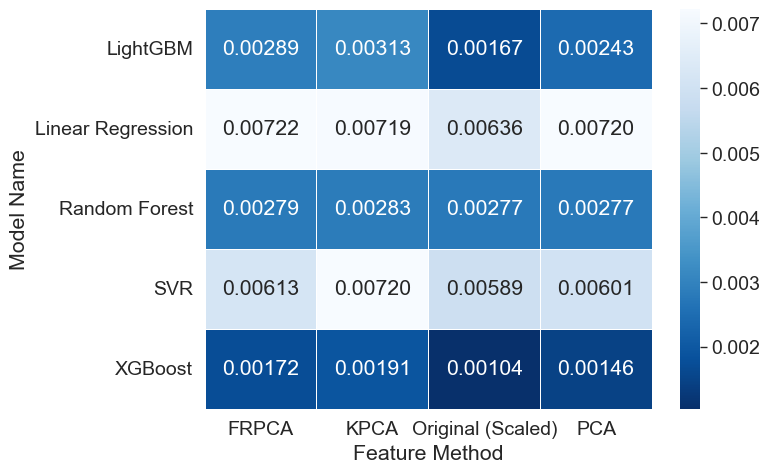

In [58]:
# 建立 Train MAE Pivot Table
pivot_train_mae = df_metrics.pivot_table(index="Model Name", 
                                         columns="Feature Method", 
                                         values="Train MAE")

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_train_mae, annot=True, fmt=".5f", cmap="Blues_r", linewidths=.5)
plt.tight_layout()
plt.show()

### test MAE

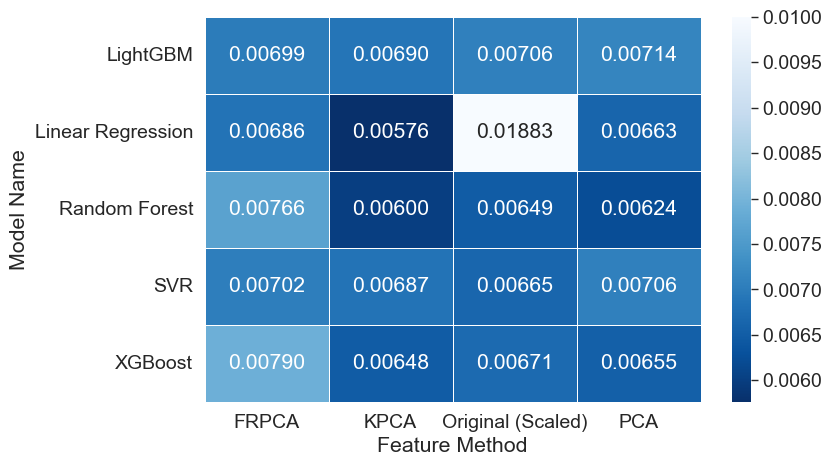

In [43]:
# 建立 Pivot Table: Index=Model, Columns=Feature, Values=Test MAE
pivot_mae = df_metrics.pivot_table(index="Model Name", 
                                   columns="Feature Method", 
                                   values="Test MAE")

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_mae, annot=True, fmt=".5f", cmap="Blues_r", linewidths=.5, vmax=0.01)
plt.show()

### Gap of test MAE - train MAE

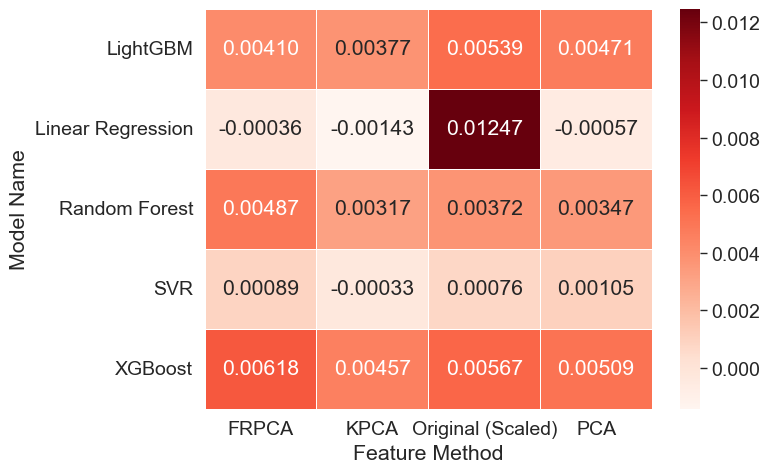

In [45]:
# 計算 Gap
df_metrics['MAE Gap'] = df_metrics['Test MAE'] - df_metrics['Train MAE']

# 建立 Gap Pivot Table
pivot_gap = df_metrics.pivot_table(index="Model Name", 
                                   columns="Feature Method", 
                                   values="MAE Gap")

plt.figure(figsize=(8, 5))
# 使用 Reds 色系，顏色越紅代表 Gap 越大 (過擬合越嚴重)
sns.heatmap(pivot_gap, annot=True, fmt=".5f", cmap="Reds", linewidths=.5)
plt.tight_layout()
plt.show()

## RMSE

### train RMSE

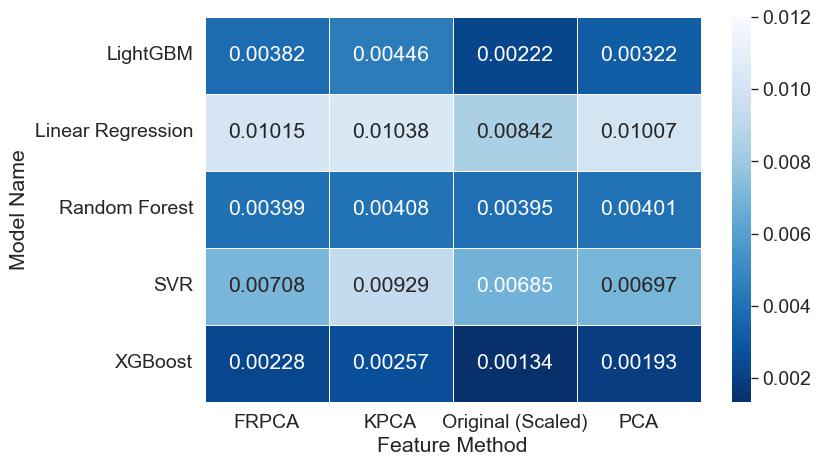

In [46]:
pivot_train_rmse = df_metrics.pivot_table(index="Model Name", 
                                   columns="Feature Method", 
                                   values="Train RMSE")

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_train_rmse, annot=True, fmt=".5f", cmap="Blues_r", linewidths=.5, vmax=0.012)
plt.show()

### test RMSE

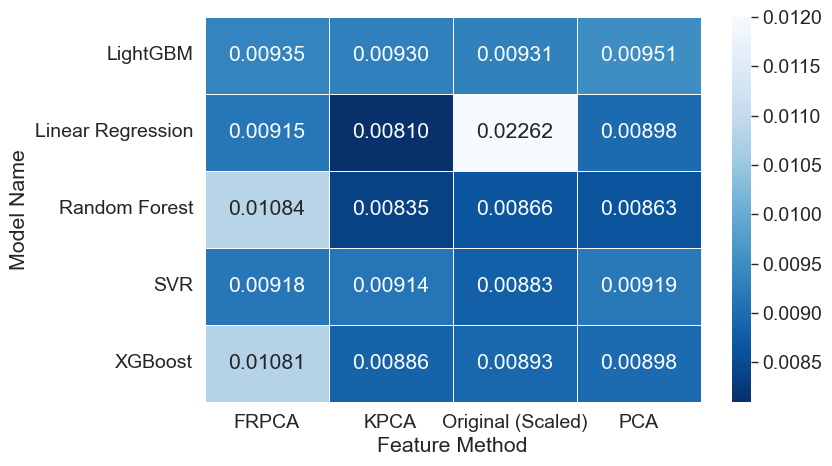

In [47]:
pivot_rmse = df_metrics.pivot_table(index="Model Name", 
                                   columns="Feature Method", 
                                   values="Test RMSE")

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_rmse, annot=True, fmt=".5f", cmap="Blues_r", linewidths=.5, vmax=0.012)
plt.show()

### Gap of test RMSE - train RMSE 

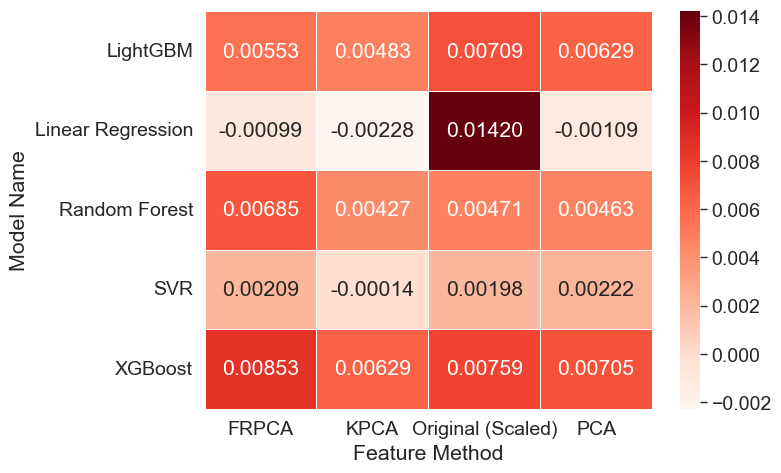

In [48]:
# 計算 Gap
df_metrics['RMSE Gap'] = df_metrics['Test RMSE'] - df_metrics['Train RMSE']

# 建立 Gap Pivot Table
pivot_gap = df_metrics.pivot_table(index="Model Name", 
                                   columns="Feature Method", 
                                   values="RMSE Gap")

plt.figure(figsize=(8, 5))
# 使用 Reds 色系，顏色越紅代表 Gap 越大 (過擬合越嚴重)
sns.heatmap(pivot_gap, annot=True, fmt=".5f", cmap="Reds", linewidths=.5)
plt.tight_layout()
plt.show()

## DA

### train DA

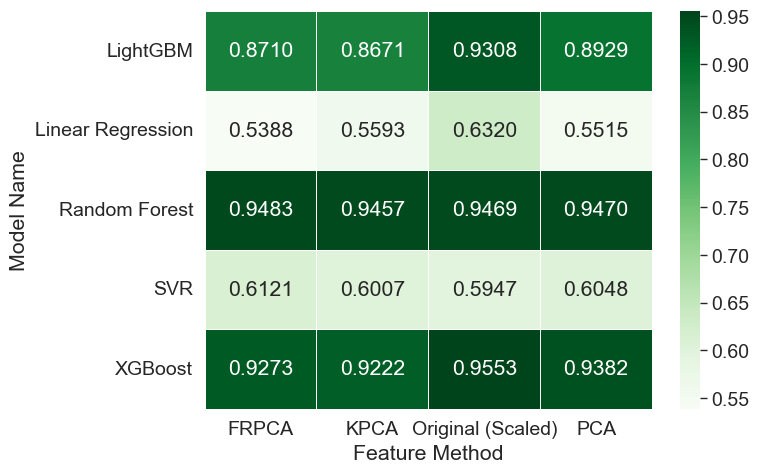

In [49]:
# 建立 Train DA Pivot Table
pivot_train_da = df_metrics.pivot_table(index="Model Name", 
                                        columns="Feature Method", 
                                        values="Train DA")

plt.figure(figsize=(8, 5))
# 使用 Greens，顏色越深代表準確率越高
sns.heatmap(pivot_train_da, annot=True, fmt=".4f", cmap="Greens", linewidths=.5)
plt.tight_layout()
plt.show()

### test DA 

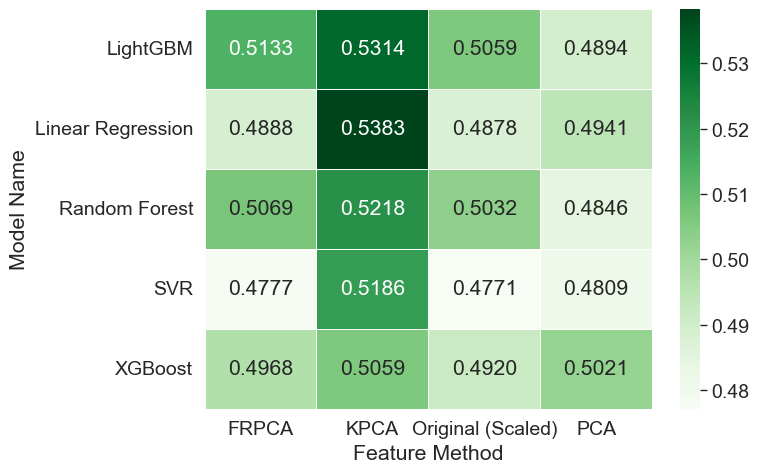

In [50]:
# 建立 Test DA Pivot Table
pivot_test_da = df_metrics.pivot_table(index="Model Name", 
                                        columns="Feature Method", 
                                        values="Test DA")

plt.figure(figsize=(8, 5))
# 使用 Greens，顏色越深代表準確率越高
sns.heatmap(pivot_test_da, annot=True, fmt=".4f", cmap="Greens", linewidths=.5)
plt.tight_layout()
plt.show()

### gap of trian DA - test DA 

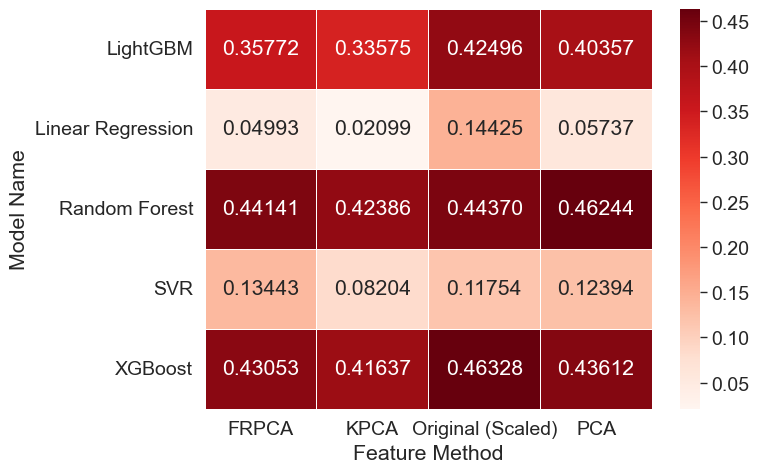

In [51]:
# 計算 Gap
df_metrics['DA Gap'] = -df_metrics['Test DA'] + df_metrics['Train DA']

# 建立 Gap Pivot Table
pivot_gap = df_metrics.pivot_table(index="Model Name", 
                                   columns="Feature Method", 
                                   values="DA Gap")

plt.figure(figsize=(8, 5))
# 使用 Reds 色系，顏色越紅代表 Gap 越大 (過擬合越嚴重)
sns.heatmap(pivot_gap, annot=True, fmt=".5f", cmap="Reds", linewidths=.5)
plt.tight_layout()
plt.show()

## Sharpe ratio

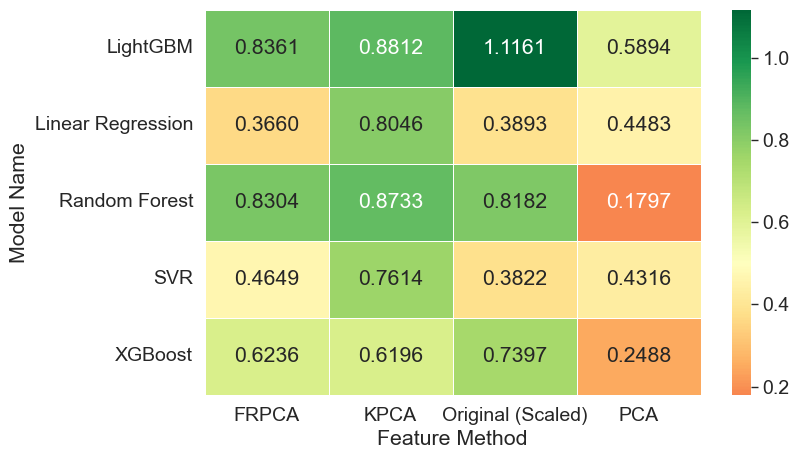

In [52]:
# 建立 Pivot Table: Values=Sharpe Ratio
pivot_sharpe = df_metrics.pivot_table(index="Model Name", columns="Feature Method", values="Sharpe Ratio")

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_sharpe, annot=True, fmt=".4f", cmap="RdYlGn", center=0.5, linewidths=.5)
plt.show()

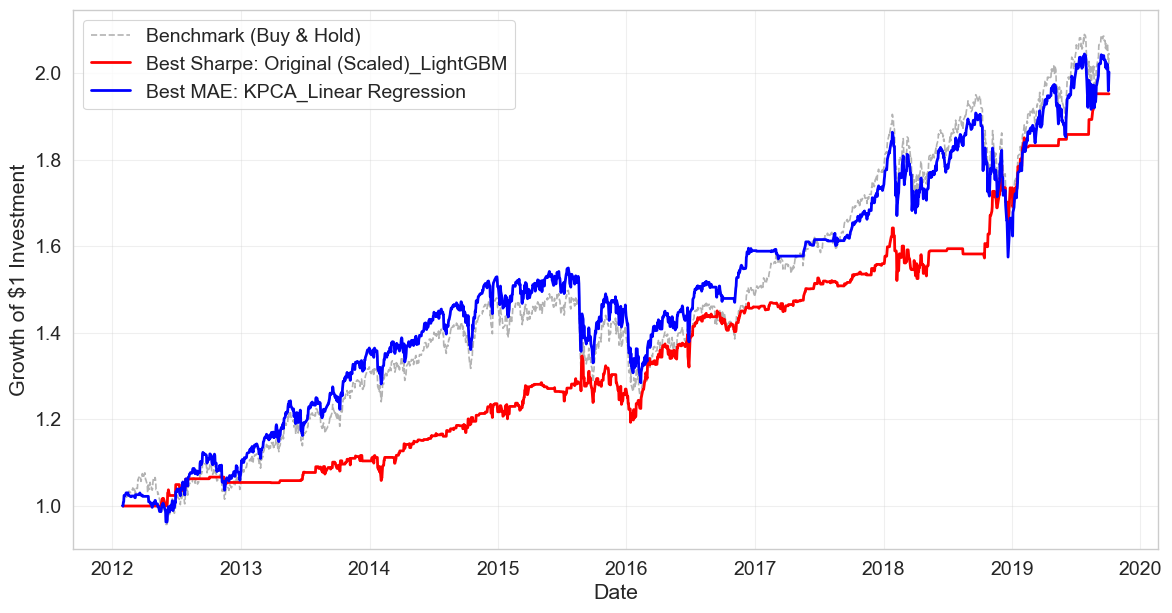

In [59]:
# 設定你的「最佳模型」名稱 (根據上面的 Heatmap 決定)
# 這裡假設你的 Sharpe 冠軍是 Original + LightGBM，統計冠軍是 KPCA + Linear Regression
model_sharpe_best = "Original (Scaled)_LightGBM" 
model_stat_best = "KPCA_Linear Regression"

# 準備畫圖資料
plt.figure(figsize=(14, 7))

# 1. 畫基準線 (Buy & Hold)
# 這邊 df_preds['Actual'] 本來就是 Series，所以沒問題
cum_benchmark = (1 + df_preds['Actual']).cumprod()
plt.plot(cum_benchmark.index, cum_benchmark, label="Benchmark (Buy & Hold)", color='gray', linestyle='--', alpha=0.6)

# 2. 畫 Sharpe 最佳模型的策略曲線
# 【修正點】：np.where 出來是 array，要轉回 Series 並補上 index
strat_ret_sharpe_array = np.where(df_preds[model_sharpe_best] > 0, df_preds['Actual'], 0)
strat_ret_sharpe = pd.Series(strat_ret_sharpe_array, index=df_preds.index) # <--- 關鍵修正

cum_sharpe = (1 + strat_ret_sharpe).cumprod()
plt.plot(cum_sharpe.index, cum_sharpe, label=f"Best Sharpe: {model_sharpe_best}", color='red', linewidth=2)

# 3. 畫 MAE 最佳模型的策略曲線
# 【修正點】：這邊也要一樣處理
strat_ret_stat_array = np.where(df_preds[model_stat_best] > 0, df_preds['Actual'], 0)
strat_ret_stat = pd.Series(strat_ret_stat_array, index=df_preds.index) # <--- 關鍵修正

cum_stat = (1 + strat_ret_stat).cumprod()
plt.plot(cum_stat.index, cum_stat, label=f"Best MAE: {model_stat_best}", color='blue', linewidth=2)

# ... (後面的 title, legend 設定不變) ...
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

In [54]:
# 根據 Sharpe Ratio 排序，取前 5 名
top_models = df_metrics.sort_values(by="Sharpe Ratio", ascending=False).head(5)

print("=== Top 5 Models by Sharpe Ratio ===")
# 只顯示重要欄位
cols_to_show = ['Feature Method', 'Model Name', 'Test RMSE', 'Test MAE', 'Test DA', 'Sharpe Ratio']
display(top_models[cols_to_show])

=== Top 5 Models by Sharpe Ratio ===


,Feature Method,Model Name,Test RMSE,Test MAE,Test DA,Sharpe Ratio
4,Original (Scaled),LightGBM,0.009314,0.007060,0.505851,1.116115
14,KPCA,LightGBM,0.009295,0.006902,0.531383,0.881163
12,KPCA,Random Forest,0.008347,0.005999,0.521809,0.873320
19,FRPCA,LightGBM,0.009351,0.006988,0.513298,0.836090
17,FRPCA,Random Forest,0.010843,0.007663,0.506915,0.830362
